Recreation of plots from:
Albeverio, S., Koshmanenko, V., & Samoilenko, I. (2009). The conflict interaction between two complex systems. Cyclic migration. arXiv. https://doi.org/10.48550/arXiv.0911.0170

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

(2.4)

$
\frac{dP}{dt} = aP \ \ - bPR \ \ - cP^2
$

$
\frac{dR}{dt} = -dR \ \ + ePR \ \ - fR^2
$

In [ ]:
def ode_LotkaVoltera(variables, t, params):
    """
    Compute the time derivatives for the Lotka–Volterra predator–prey system.

    variables: (P, R) - current populations of prey and predator
    t: time (unused, required by ODE solvers)
    params: (a, b, c, d, e, f) - model parameters

    Returns
        [dP/dt, dR/dt] — the instantaneous rates of change of prey and predator.
    """

    P, R = variables

    a, b, c, d, e, f = params

    dPdt = (a*P) - (b*P*R) - (c*P*P)
    dRdt = (-d*R) + (e*P*R) - (f*R*R)

    return([dPdt, dRdt])

(2.5)

$
P_1^{(n)} = P_1^{(n-1)} + P_1^{(n-1)}(a - bP_2^{(n-1)} - cP_1^{(n-1)})
$

$
P_2^{(n)} = P_2^{(n-1)} + P_2^{(n-1)}(-d + eP_1^{(n-1)} - fP_2^{(n-1)})
$

In [ ]:
def std_LotkaVoltera(variables, n, params, dt=0.01):
    """Simulates the standard Lotka–Volterra predator–prey model.
    Based on the classical Lotka–Volterra system described in Eq. (2.5)

    variables: (P, R) - initial populations of prey and predator
    n: total simulation time
    params: (a, b, c, d, e, f) - model parameters
    dt: time step size (default 0.01)

    Returns:
        Arrays of prey (P), predator (R), and time (t)
    """

    t = [0.0]
    # Store initial population values for prey (p1) and predator (p2)
    p1 = [variables[0]]
    p2 = [variables[1]]

    a, b, c, d, e, f = params

    # Iterate until time reaches n
    while t[-1] < n:
        # Gets values at end of lists (Most recent population values)
        p = p1[-1]
        r = p2[-1]

        # Compute rate of change for populations
        dp = p * (a - b*r - c*p)
        dr = r * (-d + e*p - f*r)

        # Update using Euler's method then add to end of lists.
        p1.append(p + dt*dp)
        p2.append(r + dt*dr)
        t.append(t[-1] + dt)

    return np.array(p1), np.array(p2), np.array(t)

In [ ]:
"""
Parameters and initial values for figure 2.
"""
#Figure 2 implies p0 = [3, 5] as it is written p0_1 = 3 and p0_2 = 5. Opposite starting points produce more similar graph:
p0 = [5, 3]
n = 2000

a, b, c, d, e, f = 0.2, 0.006, 0.002, 0.008, 0.002, 0.0
#a, b, c, d, e, f = 100, 3, 1, 4, 1, 0

params = [a, b, c, d, e, f]

In [ ]:
P1, P2, t = std_LotkaVoltera(p0, n, params, dt=0.02)

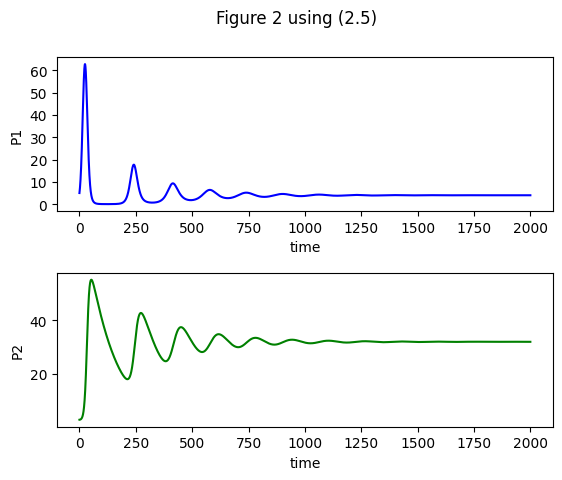

In [ ]:
# Plots standard Lotka-Volterra simulation
f, (ax1, ax2) = plt.subplots(2)

plt.suptitle("Figure 2 using (2.5)")

line1, = ax1.plot(t,P1, color='b')
line2, = ax2.plot(t,P2, color='g')

ax1.set_ylabel("P1")
ax1.set_yticks(np.arange(0, 61, 10))
ax1.set_xlabel("time")

ax2.set_ylabel("P2")
ax2.set_xlabel("time")

plt.subplots_adjust(hspace=0.4)



plt.show()

In [ ]:
t = np.linspace(0, 2000, num=n) # Creates an array of n time steps uniformly distributed between 0 and 2000
y = odeint(ode_LotkaVoltera, p0, t, args=(params,))

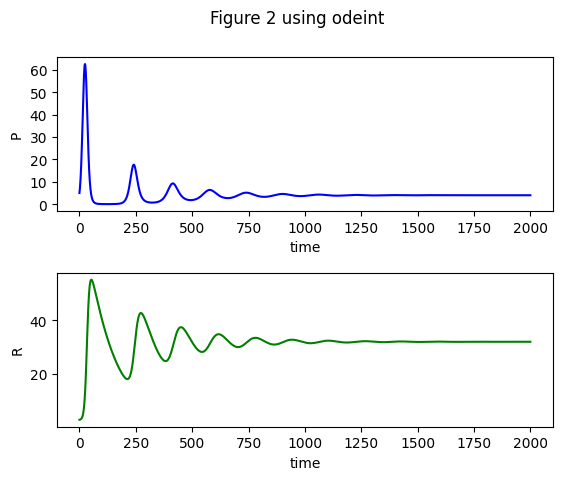

In [ ]:
# Plots the result using odeint
f, (ax1, ax2) = plt.subplots(2)
plt.suptitle("Figure 2 using odeint")
line1, = ax1.plot(t,y[:,0], color='b')
line2, = ax2.plot(t,y[:,1], color='g')

ax1.set_ylabel("P")
ax1.set_yticks(np.arange(0, 61, 10))
ax1.set_xlabel("time")

ax2.set_ylabel("R")
ax2.set_xlabel("time")

plt.subplots_adjust(hspace=0.4)

plt.show()


$
\boldsymbol{p}^0 = (p_1, ...,p_N),\boldsymbol{r}^0 = (r_1, ..., r_N) \in \mathbb{R}^N_+:
$

$
\boldsymbol{p}^1 := \boldsymbol{p}^0 * \boldsymbol{r}^1, \boldsymbol{r}^1 = \boldsymbol{r}^0 * \boldsymbol{p}^0, \boldsymbol{p}^0 \equiv \boldsymbol{p}, \boldsymbol{r}^0 \equiv \boldsymbol{r}
$

(3.1)

$
p_i^{(1)} = \frac{p_i^{(0)}(1 - αr_i^{(0)})}{1 - α\sum_{i=1}^{N}p_i^{(0)}r_i^{(0)}}, r_i^{(1)} = \frac{r_i^{(0)}(1 - αp_i^{(0)})}{1 - α\sum_{i=1}^{N}p_i^{(0)}r_i^{(0)}}
$


In [ ]:
def conflictModel(n, start, alpha):
    """
    Simulates conflict interaction between two non-annihilating systems.
    Based on the conflict transformation model described in Eq. (3.1)

    start: (p0, r0) - initial stochastic vectors for the two systems
    n: total number of iterations
    alpha: conflict interaction coefficient

    Returns:
        P, R - arrays of system states over time
    """

    p0, r0 = start

    # Initializes lists to store system states over time
    P = [p0]
    R = [r0]

    for _ in range(n-1):
        # Compute normalization factor
        z = 1 - alpha * np.inner(P[-1], R[-1])

        # Update each system according to (Eq 3.1)
        p, r = P[-1]*(1 - alpha*R[-1]) / z, R[-1]*(1 - alpha*P[-1]) / z

        # Store updated states at end of list
        P.append(p)
        R.append(r)

    return np.array(P), np.array(R)

In [ ]:
"""
Parameters and initial values for figure 3.
"""
# alpha = 1 converges too quickly, if alpha is set to 1, n should be set to 50
alpha = 0.01
p0 = np.array([0.5, 0.3, 0.2])
# Model is quite sensitive to slight change in initial values. P converges to (0.5, 0.0, 0.5).
# Similar result to Figure 3 yields r0 = np.array([0.485, 0.3375, 0.1775])
r0 = np.array([0.48, 0.34, 0.18])
start = [p0, r0]
n = 5000
t = np.linspace(0, n, num=n)

In [ ]:
p, r = conflictModel(n, start, alpha)

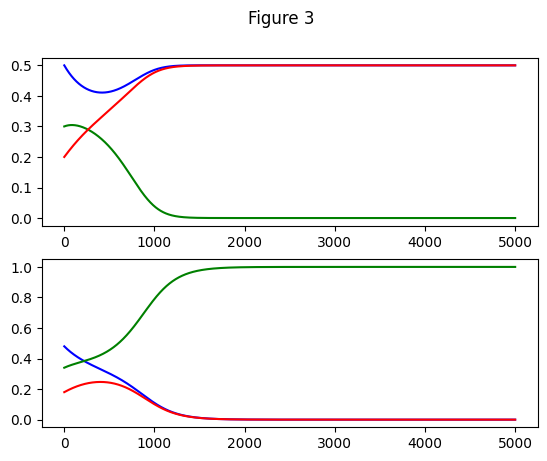

In [ ]:
# Plots graph for figure 3
f, (ax1, ax2) = plt.subplots(2)
plt.suptitle("Figure 3")
line1, = ax1.plot(t,p[:,0], color='b', label='p1')
line2, = ax1.plot(t,p[:,1], color='g', label='p2')
line3, = ax1.plot(t,p[:,2], color='r', label='p3')

line4, = ax2.plot(t,r[:,0], color='b', label='p1')
line5, = ax2.plot(t,r[:,1], color='g', label='p2')
line6, = ax2.plot(t,r[:,2], color='r', label='p3')

plt.show()

Inner Lotka-Voltera interaction

transformation $\{\boldsymbol{P}^0, \boldsymbol{R}^0\} \xrightarrow{\text{U}} \{\tilde{\boldsymbol{P}}^0,\tilde{\boldsymbol{R}}^0 \}$

$
\tilde{P}_1^{(0)} = P_1^{(0)} + P_1^{(0)}(a - bP_2^{(0)} - cP_1^{(0)}),
$

$
\tilde{P}_2^{(0)} = P_2^{(0)} + P_2^{(0)}(-d + eP_1^{(0)} - fP_2^{(0)}),
$

and

$
\tilde{R}_1^{(0)} = R_1^{(0)} + R_1^{(0)}(a - bR_2^{(0)} - cR_1^{(0)}),
$

$
\tilde{R}_2^{(0)} = R_2^{(0)} + R_2^{(0)}(-d + eR_1^{(0)} - fR_2^{(0)}),
$

normalization $\mathcal{N}\{\tilde{\boldsymbol{P}}^0,\tilde{\boldsymbol{R}}^0 \}= \{\boldsymbol{p}^0, \boldsymbol{r}^0\}$

$
\tilde{z}_P^{(0)} = \tilde{P}_1^{(0)} + \tilde{P}_2^{(0)}, \tilde{z}_R^{(0)} = \tilde{R}_1^{(0)} + \tilde{R}_2^{(0)},
$

$
p_1^{(0)} = \frac{\tilde{P}_1^{(0)}}{\tilde{z}_P^{(0)}}, p_2^{(0)} = \frac{\tilde{P}_2^{(0)}}{\tilde{z}_P^{(0)}}, r_1^{(0)} = \frac{\tilde{R}_1^{(0)}}{\tilde{z}_R^{(0)}}, r_2^{(0)} = \frac{\tilde{R}_2^{(0)}}{\tilde{z}_R^{(0)}}
$


Outer conflict interaction

$
p_i^{(j)} = \frac{p_j^{(0)}(1 - αr_j^{(0)})}{1 - α\sum_{i=1}^{N}p_i^{(0)}r_i^{(0)}}, r_j^{(1)} = \frac{r_j^{(0)}(1 - αp_j^{(0)})}{1 - α\sum_{i=1}^{N}p_i^{(0)}r_i^{(0)}}, j = 1, 2
$

convert back to non-normalized $
\mathcal{N}^{-1}\{\boldsymbol{p}^1, \boldsymbol{r}^1\}= \{\boldsymbol{P}^1, \boldsymbol{P}^1\}
$

$
P_j^{(1)} = p_j^{(1)}\tilde{z}_P^{(0)}, R_j^{(1)} = r_j^{(1)}\tilde{z}_R^{(0)}, j = 1, 2.
$

$
\boldsymbol{P}^1 = (P_1^{(1)}, P_2^{(1)}), \boldsymbol{R}^1 = (R_1^{(1)}, R_2^{(1)})
$

In [ ]:
def lv_step(params, variables, dt=1):
    """
    Performs one step of the inner Lotka–Volterra interaction.
    Based on the first step of the complex conflict transformation p.(16)

    params: (a, b, c, d, e, f) - model parameters controlling growth and interaction rates
    variables: (p, q) - current populations of prey and predator
    dt: time step size (default 1)

    Returns:
        (p1, p2) - normalized populations after one step (stochastic form)
        z - total population used for normalization
    """

    a, b, c, d, e, f = params

    # Inner Lotka-Volterra update
    p, q = variables
    P1 = p + p*dt*(a - b*q - c*p)
    P2 = q + q*dt*(-d + e*p - f*q)

    # Normalize to obtain stochastic vector
    z = P1 + P2
    p1, p2 = P1 / z, P2 / z

    return np.array([p1, p2]), z

def combinedModel(p0, r0, alpha, params, n, dt=1):
    """
    Simulates the full conflict model combining inner Lotka–Volterra
    dynamics with outer conflict interaction between two non-annihilating systems.

    Based on the complex conflict transformation p.(16-17)

    p0, r0: initial vectors for the two systems
    alpha: conflict interaction coefficient
    params: (a, b, c, d, e, f) - Lotka–Volterra parameters
    n: total simulation time
    dt: time step size (default 1)

    Returns:
        P, R, t - arrays of population vectors and time values
    """

    # Initialize time and population lists
    t = [0.0]
    P = [np.asarray(p0, dtype=float)] # population vector of system 1
    R = [np.asarray(r0, dtype=float)] # population vector of system 2

    while t[-1] < n:

        # Apply inner Lotka-Volterra step separately to both systems.
        p, z_p = lv_step(params, P[-1], dt)
        r, z_r = lv_step(params, R[-1], dt)

        # Apply outer conflict interaction
        denom = (1 - alpha * np.inner(p, r))
        p1 = p*(1 - alpha * r) / denom
        r1 = r*(1 - alpha * p) / denom

        # Convert back to non-normalized population vectors
        P1 = p1 * z_p
        R1 = r1 * z_r

        # Add results to end of lists
        P.append(P1)
        R.append(R1)
        t.append(t[-1] + dt)

    return np.array(P), np.array(R), np.array(t)

In [ ]:
"""
Parameters and initial values for figure 4.
"""
p0 = np.array([3, 10])
r0 = np.array([5, 20])
alpha = 0.005
n = 100000
a, b, c, d, e, f = 0.2, 0.006, 0.002, 0.008, 0.002, 0
params = [a, b, c, d, e, f]

In [ ]:
P, R, t = combinedModel(p0, r0, alpha, params, n)

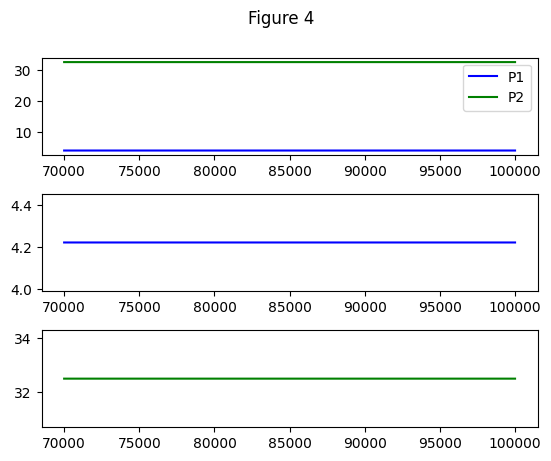

In [ ]:
# Plots the graph for figure 4
fig, (ax1, ax2, ax3) = plt.subplots(3)
plt.suptitle("Figure 4")
ax1.plot(t[70000:], P[70000:,0], color='b', label="P1")
ax1.plot(t[70000:], P[70000:,1], color='g', label="P2")

ax2.plot(t[70000:], P[70000:,0], color='b', label="P1")
ax3.plot(t[70000:], P[70000:,1], color='g', label="P2")

ax1.legend()

plt.subplots_adjust(hspace=0.4)

plt.show()

In [ ]:
# alpha = 0.007
P, R, t = combinedModel(p0, r0, 0.007, params, n)

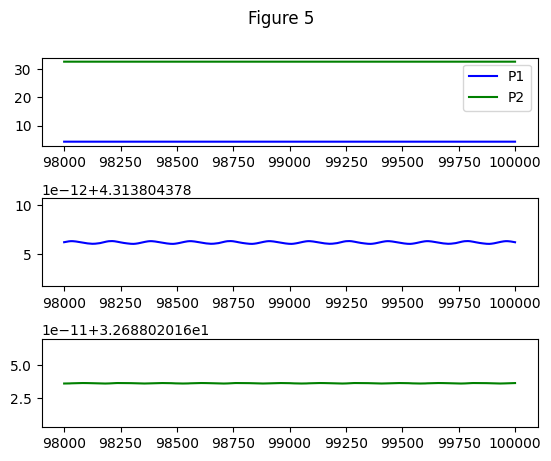

In [ ]:
# Plots the graph for figure 5
fig, (ax1, ax2, ax3) = plt.subplots(3)

plt.suptitle("Figure 5")

ax1.plot(t[98000:], P[98000:,0], color='b', label="P1")
ax1.plot(t[98000:], P[98000:,1], color='g', label="P2")

ax2.plot(t[98000:], P[98000:,0], color='b', label="P1")
ax3.plot(t[98000:], P[98000:,1], color='g', label="P2")

ax1.legend()

plt.subplots_adjust(hspace=0.6)

plt.show()

In [ ]:
"""
Parameters and initial values for figure 6-9.
"""
#initial conditions in the caption appear swapped; using P(0)=(3,7), R(0)=(5,10) matches the published trajectory.
#Figure 6 implies p0 = np.array([3, 5]), r0 = np.array([7, 10])
p0 = np.array([3, 7])
r0 = np.array([5, 10])
n = 730

#a, b, c, d, e, f = 0.2, 0.006, 0.002, 0.008, 0.002, 0.0
a, b, c, d, e, f = 100, 3, 1, 4, 1, 0

params = [a, b, c, d, e, f]

In [ ]:
P, R, t = combinedModel(p0, r0, 0.01, params, n, dt=0.01)

In [ ]:
# Rescale time by 100. Ensures evolution spans 0-n range.
t = t * 100

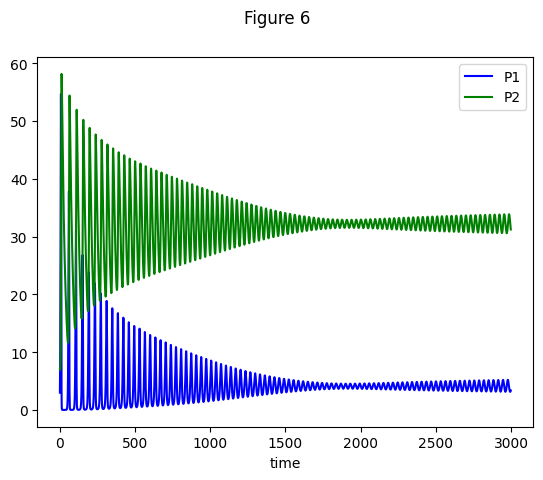

In [ ]:
# Plots graph for figure 6
fig, ax = plt.subplots()

plt.suptitle("Figure 6")

ax.plot(t[:3000], P[:3000,0], color='b', label="P1")
ax.plot(t[:3000], P[:3000,1], color='g', label='P2')

ax.set_xlabel("time")
ax.legend()

plt.show()

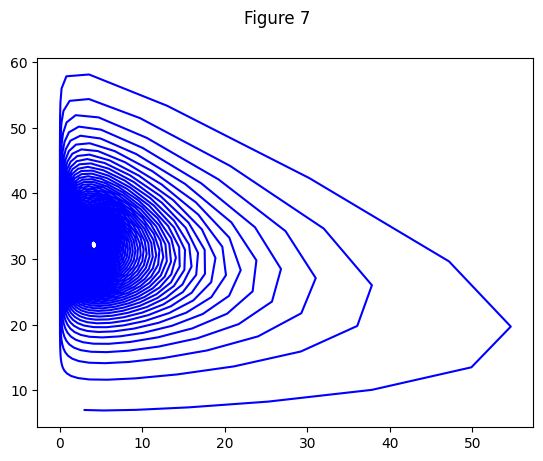

In [ ]:
# Plots graph for figure 7
fig, ax = plt.subplots()

plt.suptitle("Figure 7")

ax.plot(P[:3000,0], P[:3000,1], color='b')

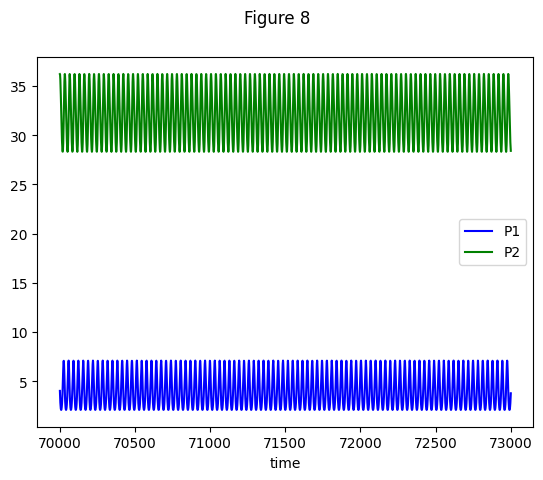

In [ ]:
# Plots graph for figure 8
fig, ax = plt.subplots()

plt.suptitle("Figure 8")

ax.plot(t[70000:], P[70000:,0], color='b', label="P1")
ax.plot(t[70000:], P[70000:,1], color='g', label='P2')

ax.set_xlabel("time")
ax.legend()

plt.show()

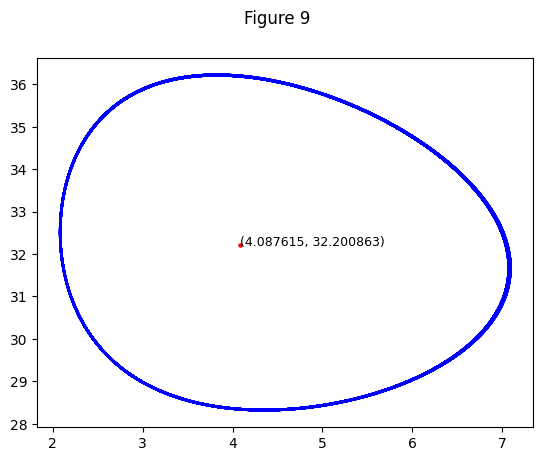

In [ ]:
# Plots graph for figure 9
fig, ax = plt.subplots()

plt.suptitle("Figure 9")

x_eq, y_eq = 4.087615, 32.200863
ax.scatter(x_eq, y_eq, color='red', s=5, label='Equilibrium Point')
ax.annotate(
    f"({x_eq:.6f}, {y_eq:.6f})",
    xy=(x_eq, y_eq),
    xytext=(x_eq,  y_eq),
    fontsize=9
)

ax.plot(P[70000:,0], P[70000:,1], color='b')

In [ ]:
"""
Parameters and initial values for figure 10,11.
"""
p0 = np.array([4, 32])
r0 = np.array([10, 20])
n = 300

#a, b, c, d, e, f = 0.2, 0.006, 0.002, 0.008, 0.002, 0.0
a, b, c, d, e, f = 100, 3, 1, 4, 1, 0

params = [a, b, c, d, e, f]

In [ ]:
P, R, t = combinedModel(p0, r0, 0.01, params, n, dt=0.01)

In [ ]:
t = t * 100

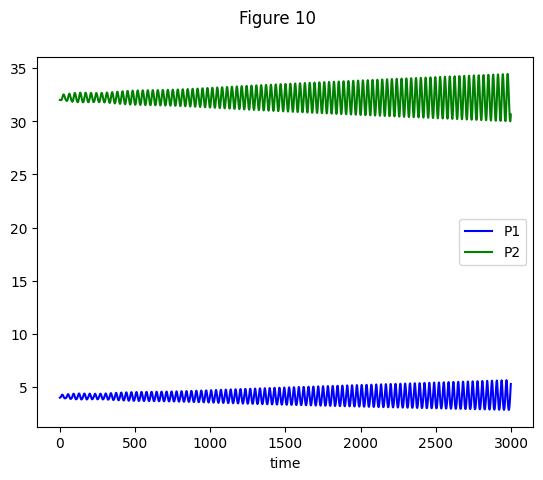

In [ ]:
# Plots graph for figure 10
fig, ax = plt.subplots()

plt.suptitle("Figure 10")

ax.plot(t[:3000], P[:3000,0], color='b', label="P1")
ax.plot(t[:3000], P[:3000,1], color='g', label='P2')

ax.set_xlabel("time")
ax.legend()

plt.show()

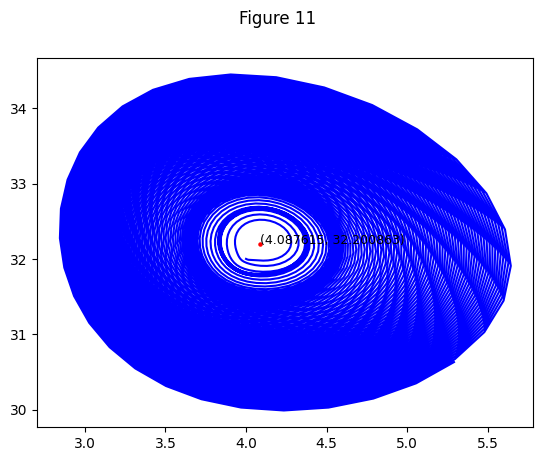

In [ ]:
# Plots graph for figure 11
fig, ax = plt.subplots()

plt.suptitle("Figure 11")

x_eq, y_eq = 4.087615, 32.200863
ax.scatter(x_eq, y_eq, color='red', s=5, label='Equilibrium Point')
ax.annotate(
    f"({x_eq:.6f}, {y_eq:.6f})",
    xy=(x_eq, y_eq),
    xytext=(x_eq,  y_eq),
    fontsize=9
)

ax.plot(P[:3000,0], P[:3000,1], color='b')